In [57]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# โหลดข้อมูลจาก database
conn = sqlite3.connect("results.db")
df = pd.read_sql("SELECT * FROM results", conn)
conn.close()

# ดูข้อมูลคร่าวๆ
print(f"ข้อมูลทั้งหมด: {len(df)} แถว")
df.head()

ข้อมูลทั้งหมด: 99 แถว


,timestamp,model,prompt,brand,mentioned,position,rank,sentiment,reason
0,2026-03-22 10:46:08,gemini-2.5-flash,ซื้อของออนไลน์ที่ไหนดีในไทย?,Allnii,0,-1,0,not_mentioned,ไม่ถูกพูดถึง
1,2026-03-22 10:46:08,gemini-2.5-flash,ซื้อของออนไลน์ที่ไหนดีในไทย?,Konvy,1,1986,4,positive,มีสินค้าให้เลือกเยอะ โปรโมชั่นดี ราคาแข่งขันได้
2,2026-03-22 10:46:08,gemini-2.5-flash,ซื้อของออนไลน์ที่ไหนดีในไทย?,EVEANDBOY,0,-1,0,not_mentioned,ไม่ถูกพูดถึง
3,2026-03-22 10:46:08,gemini-2.5-flash,ซื้อของออนไลน์ที่ไหนดีในไทย?,Beautrium,0,-1,0,not_mentioned,ไม่ถูกพูดถึง
4,2026-03-22 10:46:08,gemini-2.5-flash,ซื้อของออนไลน์ที่ไหนดีในไทย?,Sephora,1,1803,3,positive,มีแบรนด์ Exclusive โปรโมชั่นดี มีของแถมบ่อย


In [58]:
prompt_list = df['prompt'].unique()
prompt_map = {prompt: f"Q{i+1}" for i, prompt in enumerate(prompt_list)}
df['prompt_label'] = df['prompt'].map(prompt_map)

# แสดง legend บอกว่า Q1 = อะไร
print("Prompt Legend:")
for prompt, label in prompt_map.items():
    print(f"{label}: {prompt}")

Prompt Legend:
Q1: ซื้อของออนไลน์ที่ไหนดีในไทย?
Q2: แพลตฟอร์มช้อปปิ้งออนไลน์ไหนดีที่สุด?
Q3: อยากซื้อเครื่องสำอางออนไลน์ไปที่ไหนดี?
Q4: ซื้อเครื่องสำอางเคาน์เตอร์แบรนด์ออนไลน์ เว็บไหนเชื่อถือได้ ไม่โดนของปลอม?
Q5: อยากได้สกินแคร์เกาหลีแท้ 100% สั่งผ่านแอปไหนดีที่สุด?
Q6: เปรียบเทียบแอปซื้อเครื่องสำอาง อันไหนโปรโมชั่นลดราคาเยอะและส่งของไว?
Q7: แหล่งรวมสกินแคร์และเมคอัพราคาถูก มีเว็บหรือแอปอะไรแนะนำบ้าง?
Q8: ปกติคนไทยชอบซื้อสกินแคร์และเครื่องสำอางผ่านช่องทางออนไลน์ไหนกัน?


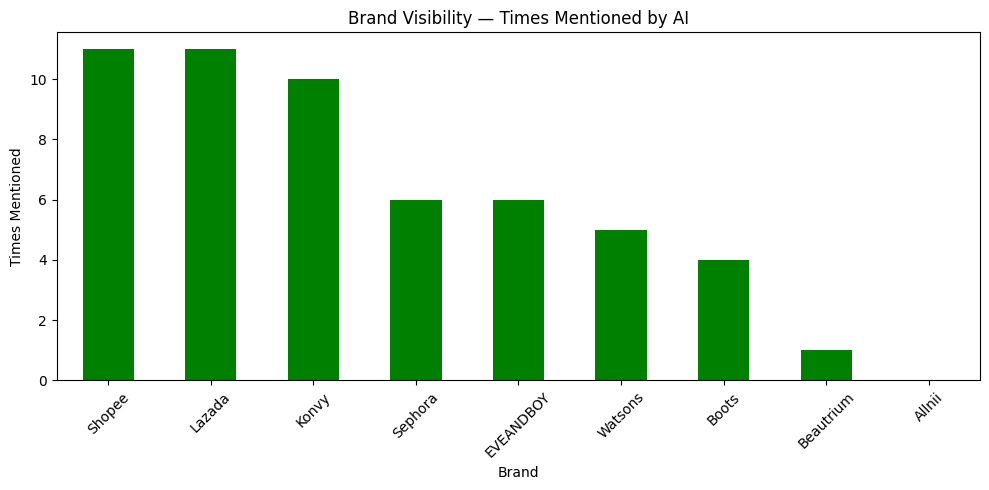

In [59]:
visibility = df.groupby('brand')['mentioned'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['green' if x > 0 else 'red' for x in visibility.values]
visibility.plot(kind='bar', color=colors)
plt.title('Brand Visibility — Times Mentioned by AI')
plt.xlabel('Brand')
plt.ylabel('Times Mentioned')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

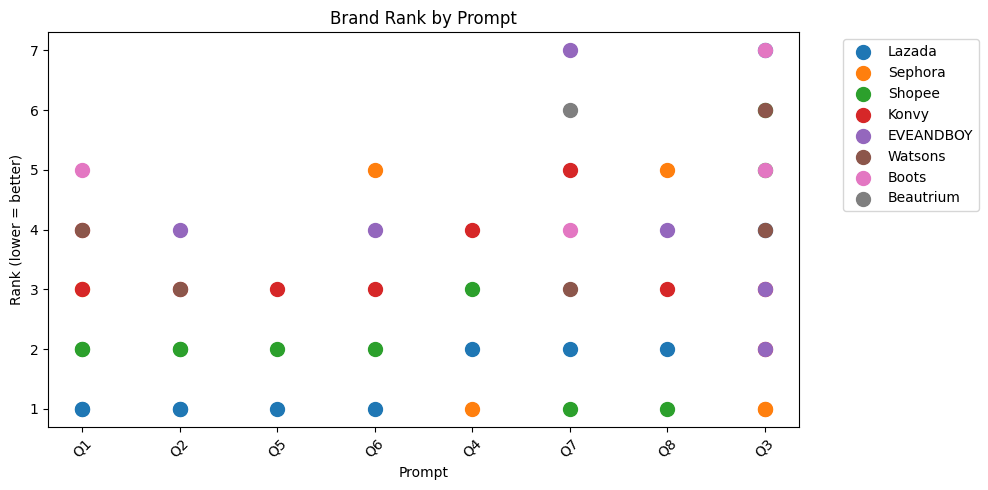

In [60]:
ranked = df[df['rank'] > 0][['brand', 'rank', 'prompt_label']].sort_values('rank')

plt.figure(figsize=(10, 5))
for brand in ranked['brand'].unique():
    data = ranked[ranked['brand'] == brand]
    plt.scatter(data['prompt_label'], data['rank'], label=brand, s=100)

plt.title('Brand Rank by Prompt')
plt.xlabel('Prompt')
plt.ylabel('Rank (lower = better)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

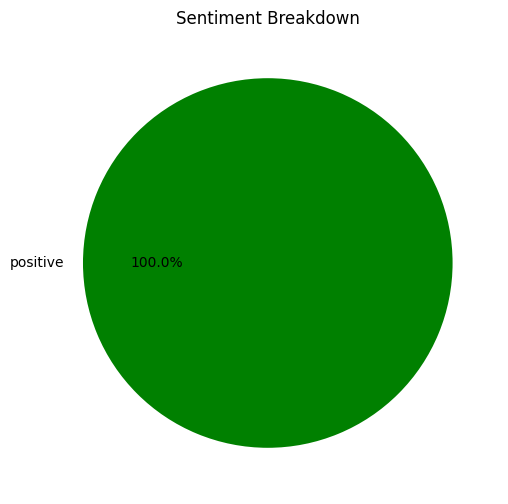

In [61]:
sentiment_counts = df[df['mentioned'] == True]['sentiment'].value_counts()

plt.figure(figsize=(6, 6))
colors = ['green', 'gray', 'red']
sentiment_counts.plot(kind='pie', autopct='%1.1f%%', colors=colors)
plt.title('Sentiment Breakdown')
plt.ylabel('')
plt.show()